My Octave Notebook 
============

Interact with Octave and the statistics-resampling package online in Jupyter Notebook with Binder. All commands are interpreted by Octave.  Since this is a [MetaKernel](https://github.com/Calysto/metakernel), a standard set of magics are available.  Help on commands is available using the `%help` magic or using `?` with a command. For the best experience, run this notebook in [Jupyter Lab](https://mybinder.org/v2/gh/acpennlab/statistics-resampling-online/master?labpath=statistics-resampling.ipynb). 

The code cells and their output below illustrate some examples of loading data and then performing analysis using functions from the **statistics-resampling** package. Follow the links in the **Quick start** section of the [README page](https://gnu-octave.github.io/statistics-resampling/readme.html), or on the [Function reference page](https://gnu-octave.github.io/statistics-resampling/function_reference), to find further examples. The example data files provided, **data1.tsv** and **data2.csv**, can be edited directly in this instance of JupyterLab. 

The statistics-resampling package already comes installed and loaded at **statistics-resampling-online**. Visit [GNU Octave Packages](https://gnu-octave.github.io/packages/) to see what other packages are available and how to install them. To load a newly installed package called `<package-name>`, use the command `pkg load <package-name>`. To preview demonstration number `X` of a function called `<function-name>`, use the command `demo ('<function-name>', X)`. To get more information about a particular function called `<function-name>`, use the command `help <function-name>`. Note that the **parallel** package cannot be installed at **statistics-resampling-online**, and that additions to the binder environment may be required to build or run some other Octave packages.

Some Octave packages come already installed and in this statistics-resampling-online Binder environment. If you were running Octave on your own machine, you would need to install and load the statistics-resampling package first by running the code in the following two cells:

In [1]:
# Run this command once to install the package
pkg install -forge statistics-resampling

The statistics-resampling package was installed into the directory:
/home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.7.0
License and copyright information can be found at:
https://github.com/gnu-octave/statistics-resampling/blob/master/COPYING


In [2]:
# Run this command in each new Octave session
pkg load statistics-resampling

Run the code in the next code cell if you wish to know:
1) The version of GNU Octave that you are running
2) What packages (and their version) are already installed (and loaded*) here
3) More information about the statistics-resampling package

In [3]:
ver('Octave');
pkg list;
pkg describe -verbose statistics-resampling

----------------------------------------------------------------------
GNU Octave Version: 8.3.0 (hg id: 6fc591af58ba)
GNU Octave License: GNU General Public License
Operating System: Linux 6.8.0-90-generic #91-Ubuntu SMP PREEMPT_DYNAMIC Tue Nov 18 14:14:30 UTC 2025 x86_64
----------------------------------------------------------------------
Package Name           | Version | Installation directory
-----------------------+---------+-----------------------
                coder  |   1.9.1 | .../octave/api-v58/packages/coder-1.9.1
              control  |   4.0.0 | .../octave/api-v58/packages/control-4.0.0
       data-smoothing  |   1.3.0 | .../api-v58/packages/data-smoothing-1.3.0
            dataframe  |   1.2.0 | .../octave/api-v58/packages/dataframe-1.2.0
               fileio  |   1.2.2 | .../octave/api-v58/packages/fileio-1.2.2
                   ga  |  0.10.4 | .../share/octave/api-v58/packages/ga-0.10.4
                   io *|   2.6.4 | .../share/octave/api-v58/packages/io-2.6.

**Example 1** (below): Bootstrap confidence intervals for the correlation coefficient using `bootci` on (bivariate) data (in wide format) loaded from **data1.tsv**. Application of `randtest2` for comparing the mean of paired samples is also illustrated.

In [4]:
# load data
[~, mutation]     = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'B2:B251');
[~, transfection] = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'C2:C251');
outcomes          = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'H2:R251');

disp (size (outcomes))

   250    11


In [5]:
# log transform before taking differences
outcomes_log = log (outcomes);

In [6]:
# separate + and - rows then subtract within each pair
plus_idx  = strcmp (transfection, '+');
minus_idx = strcmp (transfection, '-');

outcomes_diff = outcomes_log(plus_idx, :) - outcomes_log(minus_idx, :);
mutation_diff = mutation(plus_idx);

disp (size (outcomes_diff))
disp (unique (mutation_diff))

   125    11
{
  [1,1] = C436R
  [2,1] = K669N
  [3,1] = L812M
  [4,1] = R518H
  [5,1] = T531M
  [6,1] = WT
}


In [7]:
# This is a sanity check
for m = {'C436R','K669N','L812M','R518H','T531M','WT'}
  fprintf ('%s: %d pairs\n', m{1}, sum (strcmp (mutation_diff, m{1})))
end

# WT differences should be close to 0
WT_idx = strcmp (mutation_diff, 'WT');
disp (mean (outcomes_diff(WT_idx, :)))

C436R: 17 pairs
K669N: 29 pairs
L812M: 27 pairs
R518H: 17 pairs
T531M: 17 pairs
WT: 18 pairs
 Columns 1 through 6:

  -2.3472e-01  -2.4666e-02  -2.7401e-01   1.3170e-01   1.2259e-01  -1.1105e-01

 Columns 7 through 11:

   1.2762e-01   1.7635e-02  -8.7821e-03  -6.9755e-02  -2.0635e-02



MODEL FORMULA (based on Wilkinson's notation):

Y ~ 1 + X1

MODEL COEFFICIENTS

name                                   coeff       CI_lower    CI_upper    p-val
--------------------------------------------------------------------------------
(Intercept)                            -0.2347     -0.4587     -0.01071     .041
X1_1                                   -0.1445     -0.4360     +0.1470      .323
X1_2                                   -0.09552    -0.3733     +0.1822      .493
X1_3                                   -0.2274     -0.5647     +0.1100      .185
X1_4                                   -0.2257     -0.4843     +0.03294     .086
X1_5                                   -0.3001     -0.6702     +0.06994     .115

mdl =

  scalar structure containing the fields:

    method = Wild bootstrap-t
    name =
    {
      [1,1] = (Intercept)
      [1,2] = X1_1
      [1,3] = X1_2
      [1,4] = X1_3
      [1,5] = X1_4
      [1,6] = X1_5
    }

    estimate =

      -0.234719
      -0.1444

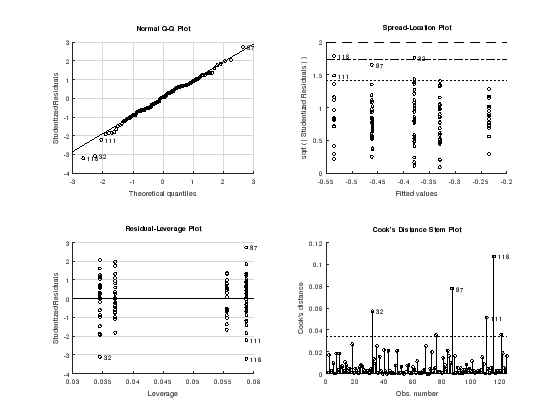

In [8]:
# treatment contrast, WT as reference
mdl = bootlm (outcomes_diff(:,1), {mutation_diff})

In [9]:
mdl

mdl =

  scalar structure containing the fields:

    method = Wild bootstrap-t
    name =
    {
      [1,1] = (Intercept)
      [1,2] = X1_1
      [1,3] = X1_2
      [1,4] = X1_3
      [1,5] = X1_4
      [1,6] = X1_5
    }

    estimate =

      -0.234719
      -0.144479
      -0.095516
      -0.227388
      -0.225668
      -0.300110

    CI_lower =

      -0.4587
      -0.4360
      -0.3733
      -0.5647
      -0.4843
      -0.6702

    CI_upper =

      -0.010711
       0.147006
       0.182239
       0.109950
       0.032937
       0.069941

    pval =

       0.040690
       0.322749
       0.493263
       0.184557
       0.086381
       0.114505

    fpr =

       0.2615
       0.4980
       0.5000
       0.4588
       0.3651
       0.4028

    N = 125
    prior = [](0x0)
    levels =
    {
      [1,1] =
      {
        [1,1] = WT
        [2,1] = K669N
        [3,1] = L812M
        [4,1] = C436R
        [5,1] = T531M
        [6,1] = R518H
      }

    }

    contrasts =
    {
   

In [10]:
# Load data from tab-separated-value (TSV) file (i.e. tab-delimited text file) with header
# Formatting: each %f corresponds to a number (double precision)
[before, after] = textread ('../data/data1.tsv', '%f %f', 'Delimiter', '', 'HeaderLines', 1);

# 95% BCa bootstrap confidence intervals for the correlation coefficient
ci = bootci (1999, @cor, before, after)

# Randomization test for comparing means of paired samples
pval = randtest2 (before, after, true, 10000, @(A, B) mean (A) - mean (B))

ci =

   0.4896
   0.8582

pval = 3.5294e-04


**Example 2** (below): Bootstrap two-way ANOVA (Type I) using `bootlm` with data (in long format) loaded from **data2.csv**.

ANOVA SUMMARY with effect of gender averaged over levels of degree
F(1,18) = 87.20, p = 0.0001 for the model: salary ~ 1 + degree
F(1,18) = 10.97, p = 0.0111 for the model: salary ~ 1 + degree + gender
F(1,18) = 0.42, p = 0.573 for the model: salary ~ 1 + degree + gender + degree:gender

MODEL FORMULA (based on Wilkinson's notation):

salary ~ 1 + degree + gender + degree:gender

MODEL COEFFICIENTS

name                                   coeff       CI_lower    CI_upper         
--------------------------------------------------------------------------------
(Intercept)                            +20.00      +19.14      +20.92           
degree_1                               +7.000      +5.229      +8.822           
gender_1                               -3.000      -4.714      -1.094           
degree:gender_1                        +1.000      -1.623      +3.587           


MODEL FORMULA (based on Wilkinson's notation):

salary ~ 1 + degree + gender + degree:gender

MODEL ESTIMATED

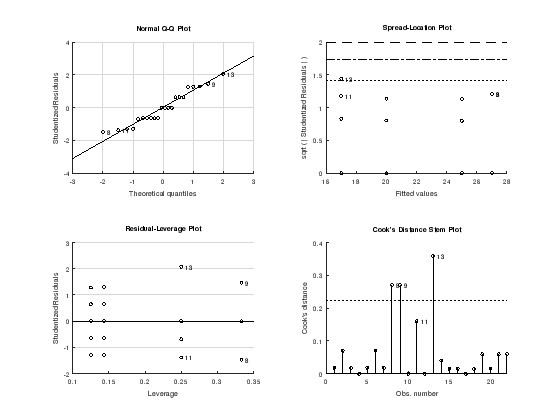

In [11]:
# Load data from comma-separated-value (CSV) file with header
# Formatting: each %d, %s and %f corresponds to an integer, a string and a
# number (double precision) respectively
[degree, gender, salary] = textread ('../data/data2.csv', '%d %s %f', 'Delimiter', ',', 'HeaderLines', 1);

# ANOVA using wild bootstrap
# https://gnu-octave.github.io/statistics-resampling/function/bootlm.html#7
[STATS, BOOTSTAT, AOVSTAT] = bootlm (salary, {degree, gender}, 'model', ...
                             'full', 'display', 'off', 'varnames', ...
                             {'degree', 'gender'}, 'seed', 1);

# Report ANOVA results
fprintf ('ANOVA SUMMARY with effect of gender averaged over levels of degree\n')
for i = 1:numel(AOVSTAT.MODEL)
  fprintf ('F(%u,%u) = %.2f, p = %.3g for the model: %s\n', ...
           AOVSTAT.DF(i), AOVSTAT.DFE, AOVSTAT.F(i), ...
           AOVSTAT.PVAL(i), AOVSTAT.MODEL{i});
end

# Calculate regression coefficients and 95% credible intervals (using bayesian bootstrap
# with an uninformative prior)
MDL = bootlm (salary, {degree, gender}, 'model', 'full', ...
                        'display', 'on', 'varnames', ...
                        {'degree', 'gender'}, 'method', 'bayesian', 'prior', 1);

# Calculate estimated marginal means and 95% credible intervals (using bayesian bootstrap
# with an uninformative prior)
EMMEANS = bootlm (salary, {degree, gender}, 'model', 'full', ...
                        'display', 'on', 'varnames', ...
                        {'degree', 'gender'}, 'dim', [1, 2], ...
                        'method', 'bayesian', 'prior', 'auto');

# Test whether salaries averaged over levels of college differ between men and 
# women (using wild bootstrap)
POSTTESTS = bootlm (salary, {degree, gender}, 'model', 'full', ...
                        'display', 'on', 'varnames', ...
                        {'degree', 'gender'}, 'dim', 2, ...
                        'posthoc', [1, 2]);

# Save the figure of the diagnostic plots
print ('../output/diagnostic_plots.svg','-dsvg')
#print ('../output/diagnostic_plots.png','-dpng','-r300')

**Example 3** (below): Bootstrap two-way ANOVA (Type I) using `bootlm` with data (in long format) as above but loaded from **data.xlsx**.

In [12]:
# Load data from Microsoft Excel or Open Office document spreadsheet
# First output is for numeric data, second output is for text data
# https://octave.sourceforge.io/io/function/xlsread.html
[degree, gender] = xlsread ('../data/data.xlsx', 'data2', 'A2:B23');
salary = xlsread ('../data/data.xlsx', 'data2', 'C2:C23');

# As above, ANOVA using wild bootstrap
[STATS, BOOTSTAT, AOVSTAT] = bootlm (salary, {degree, gender}, 'model', ...
                             'full', 'display', 'off', 'varnames', ...
                             {'degree', 'gender'}, 'seed', 1);

# Report ANOVA results
fprintf ('ANOVA SUMMARY with effect of gender averaged over levels of degree\n')
for i = 1:numel(AOVSTAT.MODEL)
  fprintf ('F(%u,%u) = %.2f, p = %.3g for the model: %s\n', ...
           AOVSTAT.DF(i), AOVSTAT.DFE, AOVSTAT.F(i), ...
           AOVSTAT.PVAL(i), AOVSTAT.MODEL{i});
end

ANOVA SUMMARY with effect of gender averaged over levels of degree
F(1,18) = 87.20, p = 0.0001 for the model: salary ~ 1 + degree
F(1,18) = 10.97, p = 0.0111 for the model: salary ~ 1 + degree + gender
F(1,18) = 0.42, p = 0.573 for the model: salary ~ 1 + degree + gender + degree:gender


**Example 4** (below): Bootstrap confidence intervals using `bootci` or `bootknife` with data specified in the code cell.

In [13]:
# Spatial Test Data from Table 14.1 of Efron and Tibshirani (1993)
# An Introduction to the Bootstrap in Monographs on Statistics and Applied 
# Probability 57 (Springer)
# AIM:
# To construct 90% nonparametric bootstrap confidence intervals for var(A,1)
# var(A,1) = 171.5
# Exact intervals based on Normal theory are [118.4, 305.2]
A = [48 36 20 29 42 42 20 42 22 41 45 14 6 ...
    0 33 28 34 4 32 24 47 41 24 26 30 41].';
ci1 = bootci (4999,{{@var,1},A},'alpha',0.1,'type','norm','seed',1);
ci2 = bootci (4999,{{@var,1},A},'alpha',0.1,'type','per','seed',1);
ci3 = bootci (4999,{{@var,1},A},'alpha',0.1,'type','basic','seed',1);
ci4 = bootci (4999,{{@var,1},A},'alpha',0.1,'type','bca','seed',1);
ci5 = bootci (4999,{{@var,1},A},'alpha',0.1,'type','stud','nbootstd',100,'seed',1);
ci6 = bootci (4999,{{@var,1},A},'alpha',0.1,'type','cal','nbootcal',499,'seed',1);

# Create table of confidence intervals using bootci
header = {'', 'norm', 'perc', 'basic', 'bca', 'stud', 'cal'};
tbl = table ({'CI_lower'; 'CI_upper'}, ci1, ci2, ci3, ci4, ci5, ci6);
tbl = setVariableNames (tbl, (1:7), header);
prettyprint (tbl(:,:))

# Bias-corrected and accelerated bootstrap confidence intervals after balanced bootknife resampling 
bootknife (A,4999,{@var,1},[0.05,0.95]);

# Calibrated bootstrap confidence intervals after iterated balanced bootknife resampling 
bootknife (A,[4999,499],{@var,1},[0.05,0.95]);

------------------------------------------------------------------------------
|          | norm     | perc     | basic    | bca      | stud     | cal      |
------------------------------------------------------------------------------
| CI_lower | 108.9991 | 97.01331 | 104.2456 | 116.2469 | 114.1905 | 114.1305 |
| CI_upper | 246.8654 | 235.0902 | 245.7781 | 264.3331 | 292.4748 | 281.0163 |
------------------------------------------------------------------------------

Summary of nonparametric bootstrap estimates of bias and precision
******************************************************************************

Bootstrap settings: 
 Function: var
 Resampling method: Balanced, bootknife resampling 
 Number of resamples (outer): 4999 
 Number of resamples (inner): 0 
 Confidence interval (CI) type: Bias-corrected and accelerated (BCa) 
 Nominal coverage (and the percentiles used): 90% (12.2%, 98.7%)

Bootstrap Statistics: 
 original     bias         std_error    CI_lower     CI_upper 

In [14]:
# contrast matrix from Table S1
# rows must match alphabetical order of mutations: C436R, K669N, L812M, R518H, T531M, WT
#          A      B      C      D      E
contrast_S1 = [
  1/6, -2/5, -1/3, -1/2,    0;  # C436R
  1/6,  3/5,    0,    0, -1/2;  # K669N
  1/6,  3/5,    0,    0,  1/2;  # L812M
  1/6, -2/5,  2/3,    0,    0;  # R518H
  1/6, -2/5, -1/3,  1/2,    0;  # T531M
 -5/6,    0,    0,    0,    0;  # WT
];

disp (contrast_S1)

   0.1667  -0.4000  -0.3333  -0.5000        0
   0.1667   0.6000        0        0  -0.5000
   0.1667   0.6000        0        0   0.5000
   0.1667  -0.4000   0.6667        0        0
   0.1667  -0.4000  -0.3333   0.5000        0
  -0.8333        0        0        0        0


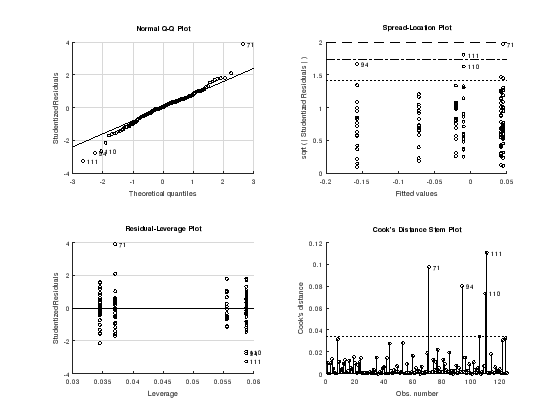

In [15]:
# diagnostic plots for each outcome
for i = 1:size (outcomes_diff, 2)
  MAT_T = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                  'model', 'linear', 'display', 'on', ...
                  'contrasts', {contrast_S1}, 'nboot', 0);
  print (sprintf ('../output/GRIN2A_outcome%d.png', i), '-dpng', '-r300')
end

In [16]:
# can't do cluster bootstrap yet so Deff = 1
Deff = 1

Deff = 1


In [17]:
# build design matrix using Table S1 contrasts
MAT = bootlm (outcomes_diff(:,1), {mutation_diff}, ...
              'model', 'linear', 'display', 'off', ...
              'contrasts', {contrast_S1}, 'nboot', 0, 'dim', 1);
MAT.C

MAT = bootlm (outcomes_diff(:,1), {mutation_diff}, ...
              'model', 'linear', 'display', 'off', ...
              'contrasts', MAT.C, 'nboot', 0, 'dim', 1);

size (MAT.X)

ans =
{
  [1,1] =

     0.1667  -0.4000  -0.3333  -0.5000        0
     0.1667   0.6000        0        0  -0.5000
     0.1667   0.6000        0        0   0.5000
     0.1667  -0.4000   0.6667        0        0
     0.1667  -0.4000  -0.3333   0.5000        0
    -0.8333        0        0        0        0

}

ans =

   125     6




 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 125

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 10.0913

 Predicted R-squared: 0.083 (8.3%)

 Bootstrap optimized ridge tuning constant (lambda): 3.38272

 Effective residual degrees of freedom (df_lambda): 120.

 Residual variances (range): [0.0795, 0.396]

 Inferential degrees of freedom (df_t): 120.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.04235      -0.2209       +0.1390  
 1             3             +0.7219       +0.6227       +0.7983  
 1             4             +0.07038      -0.111

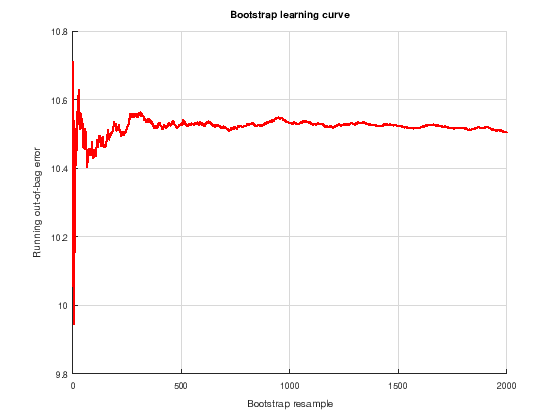

In [18]:
# ridge regression on all 11 outcomes
tic
bootridge (outcomes_diff, MAT.X, '*', 1999, 0.05, [], Deff);
toc
ridge_coeff = ans;

In [19]:
disp (ridge_coeff.stability * 100)

 Columns 1 through 8:

      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN
   84.775   99.725   57.725   98.475   99.975   73.675   73.375   55.925
   64.925   97.425   93.475   97.975   98.775   99.575   99.925   80.075
   78.975   99.675   85.125   95.575   96.425   76.875   95.225   68.275
   96.575   99.975   99.925   99.975   99.975   85.325   98.325   51.975
   64.075   64.775   73.525   99.275   99.875   53.525   86.225   68.325

 Columns 9 through 11:

      NaN      NaN      NaN
   49.525   53.475   58.825
   88.675   98.825   97.975
   74.175   71.275   58.125
   77.875   79.975   91.175
   95.175   60.025   49.875


In [20]:
ridge_coeff.BF10

ans =

 Columns 1 through 6:

          NaN          NaN          NaN          NaN          NaN          NaN
   8.2810e-01   9.1077e+00   4.4741e-01   1.7075e+00   4.3249e+00   5.2166e-01
   3.5133e-01   2.1396e+00   8.0890e-01   2.3050e+00   4.0059e+00   4.1670e+00
   6.1042e-01   1.3483e+01   7.4619e-01   2.6923e+00   4.0224e+00   5.8053e-01
   1.0314e+00   1.1196e+05   6.9732e+00   1.8950e+08   1.6546e+09   6.5424e-01
   4.6650e-01   4.6358e-01   5.0202e-01   3.0550e+00   6.4235e+00   4.4258e-01

 Columns 7 through 11:

          NaN          NaN          NaN          NaN          NaN
   5.0364e-01   4.3901e-01   4.3406e-01   4.3741e-01   4.4389e-01
   2.8661e+01   4.4878e-01   5.8738e-01   2.0517e+00   1.8111e+00
   9.3207e-01   5.1933e-01   5.5091e-01   5.1816e-01   4.8299e-01
   1.4064e+00   5.2820e-01   6.6169e-01   7.0503e-01   8.9171e-01
   8.8119e-01   4.8355e-01   9.0604e-01   4.5139e-01   4.4150e-01



In [21]:
RTAB = ridge_coeff.RTAB;
disp (min (RTAB(:,3)));
disp (max (RTAB(:,3)));

-0.1731
0.9847



 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 125

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 10.0913

 Predicted R-squared: 0.083 (8.3%)

 Bootstrap optimized ridge tuning constant (lambda): 3.38272

 Effective residual degrees of freedom (df_lambda): 120.

 Residual variances (range): [0.0795, 0.396]

 Inferential degrees of freedom (df_t): 120.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.04235      -0.2209       +0.1390  
 1             3             +0.7219       +0.6227       +0.7983  
 1             4             +0.07038      -0.111

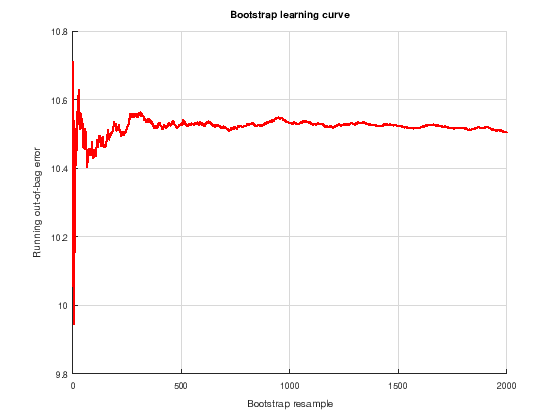

In [22]:
tic
bootridge (outcomes_diff, MAT.X, '*', 1999, 0.05, MAT.L, Deff);
toc
ridge_emm = ans;